In [1]:
import cme.simulators.diffusion_random_walk as drw
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
theta, alpha, tau = 5, 1.5, 0.01

mu, sigma = np.asarray([1.2]), np.asarray([1])
RT_arr, X_arr, steps_arr = drw.gen_rt_x(theta, alpha, tau, sigma[0], mu,samples = 100, process="Wiener",njobs=1)
RT_arr

[3.7800000000000002,
 1.77,
 14.530000000000001,
 2.5300000000000002,
 2.46,
 4.95,
 3.2600000000000002,
 4.96,
 4.95,
 4.92,
 11.49,
 4.41,
 3.43,
 2.65,
 7.42,
 6.24,
 4.14,
 6.47,
 3.73,
 2.57,
 1.28,
 2.11,
 5.13,
 4.5200000000000005,
 3.7800000000000002,
 8.540000000000001,
 1.67,
 3.8000000000000003,
 4.3500000000000005,
 1.82,
 1.71,
 5.25,
 4.2700000000000005,
 5.62,
 3.22,
 3.65,
 4.42,
 1.3800000000000001,
 1.02,
 1.49,
 5.7700000000000005,
 2.64,
 5.39,
 4.38,
 5.09,
 6.98,
 7.45,
 2.0300000000000002,
 2.16,
 7.0600000000000005,
 5.37,
 7.79,
 2.35,
 6.6000000000000005,
 4.93,
 7.8100000000000005,
 1.85,
 3.5300000000000002,
 2.21,
 4.38,
 1.52,
 11.040000000000001,
 10.08,
 5.7,
 2.39,
 3.97,
 2.9,
 1.19,
 6.5200000000000005,
 5.22,
 2.25,
 5.01,
 1.6600000000000001,
 3.17,
 2.56,
 8.61,
 6.24,
 2.42,
 2.33,
 4.66,
 3.6,
 4.4,
 2.14,
 2.49,
 3.02,
 7.08,
 2.93,
 1.99,
 2.02,
 4.3,
 3.7800000000000002,
 7.11,
 3.2,
 3.13,
 1.3,
 2.39,
 3.23,
 2.19,
 4.82,
 5.32]

<Axes: ylabel='Density'>

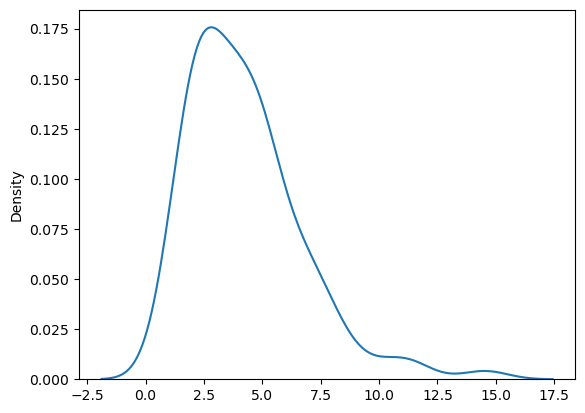

In [3]:
sns.kdeplot(RT_arr)

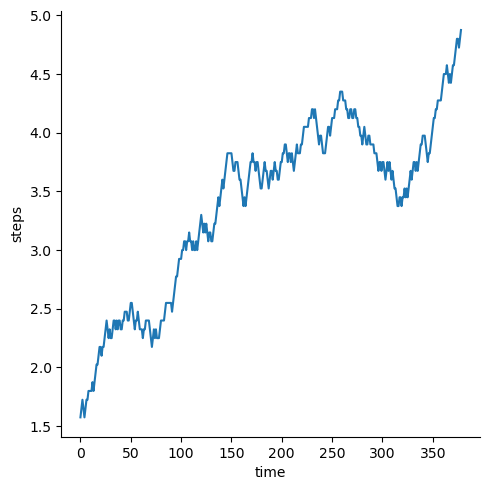

In [4]:
sns.relplot(pd.DataFrame({"steps":np.asarray(steps_arr[0])}).reset_index(names="time"),
x="time",
y="steps", kind="line")

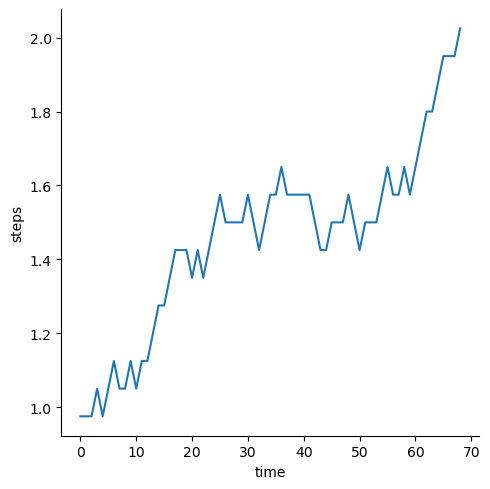

In [5]:
# plot for NDAR_INV01AJ15N9
# alpha: 2.2198321041134936	beta:0.6202451435615302	delta:1.964868726067117	nondecision:0.3208593807756497	rt_mean: 0.7831230833333334

theta, alpha, tau = 2.2198321041134936, 1.5, 0.01

mu, sigma = np.asarray([1.964868726067117]), np.asarray([1])
RT_arr, X_arr, steps_arr = drw.gen_rt_x(theta, alpha, tau, sigma, mu,samples = 1, process="Wiener",njobs=1)
sns.relplot(pd.DataFrame({"steps":np.asarray(steps_arr[0])}).reset_index(names="time"),
x="time",
y="steps", kind="line")

In [6]:
steps_arr[0].shape

(69,)

In [7]:
#df_cong.assign(time = lambda df: df.time*tau).to_csv("steps_congruent.csv", index=False)
#df_incong.assign(time = lambda df: df.time*tau).to_csv("steps_incongruent.csv", index=False)

In [8]:
df_cong = pd.read_csv("steps_congruent.csv")
df_incong = pd.read_csv("steps_incongruent.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'steps_congruent.csv'

(0.0, 2.2575000000000003)

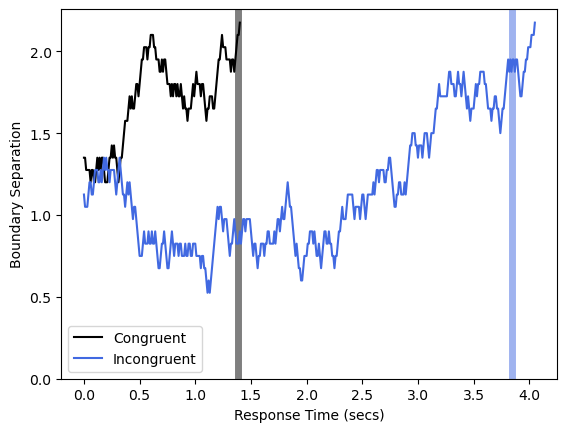

In [9]:
# plot for NDAR_INVFD34548C # Congruent 
RT_c = 1.3826

theta, alpha, tau = 2.3393051181422084, 1.5, 0.01

mu, sigma = np.asarray([1.5006808654556705]), np.asarray([1])
#_, _, steps_arr_c = drw.gen_rt_x(theta, alpha, tau, sigma, mu,samples = 1, process="Wiener",initial="Fixed", njobs=1, bias=0.58120)
#df_cong = pd.DataFrame({"steps":np.asarray(steps_arr_c[0])}).reset_index(names="time")

ax = sns.lineplot(df_cong,
x="time",
y="steps", color="black", label="Congruent")

ax.axvline(x=RT_c,  lw=5, color="black", alpha=0.5)


# plot for NDAR_INVFD34548C # Incongruent 
RT_in = 3.8444

theta, alpha, tau = 2.343104690312368, 1.5, 0.01

mu, sigma = np.asarray([0.129081165432872]), np.asarray([1])
#_, _, steps_arr_in = drw.gen_rt_x(theta, alpha, tau, sigma, mu,samples = 1, process="Wiener",initial="Fixed",njobs=1, bias=0.57841)
#df_incong = pd.DataFrame({"steps":np.asarray(steps_arr_in[0])}).reset_index(names="time")

ax = sns.lineplot(df_incong,
x="time",
y="steps", color="royalblue", label="Incongruent")
ax.axvline(x=RT_in, lw=5, color="royalblue", alpha=0.5)

ax.set_ylabel("Boundary Separation")
ax.set_xlabel("Response Time (secs)")
plt.legend()
plt.ylim((0,None))